Before imputation:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

After imputation:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


C:\Users\anaku\AppData\Local\Temp\ipykernel_50448\1626026059.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic_df['age'].fillna(titanic_df['age'].mean(),inplace=True)


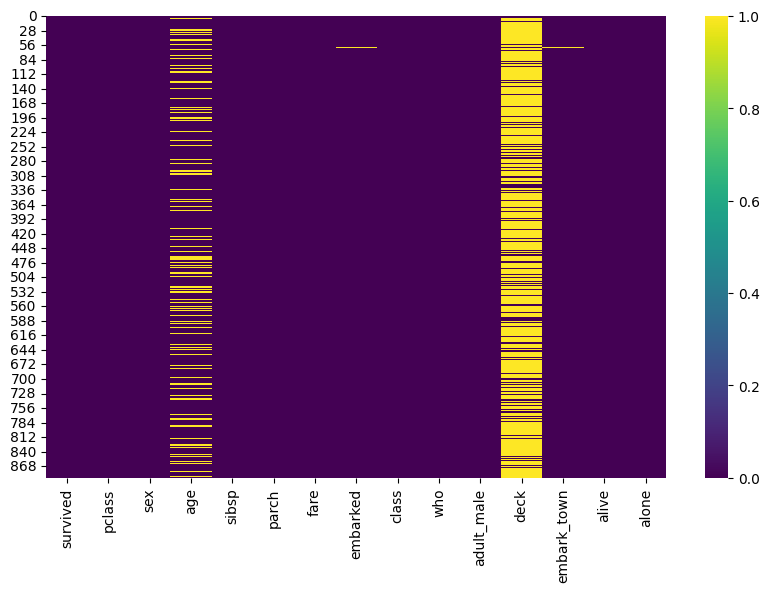

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

titanic_df = sns.load_dataset('titanic')

# Print out the number of missing values in each column
print('Before imputation:')
print(titanic_df.isnull().sum())

# Impute missing values in the 'age' column with its mean
titanic_df['age'].fillna(titanic_df['age'].mean(),inplace=True)

# Check again the number of missing values
print('\nAfter imputation:')
print(titanic_df.isnull().sum())

plt.figure(figsize=(10,6))
sns.heatmap(titanic_df.isnull(), cmap='viridis')
plt.show()

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np

# Load Titanic dataset
titanic = sns.load_dataset('titanic')

# Create a new feature, 'age_x_fare'
titanic['age_x_fare'] = titanic['age']*titanic['fare']

# Check if new feature 'age_x_fare' was added
print("Data with new feature 'age_x_fare':")
print(titanic.head(5))

# Create age groups using bins
bins= [0, 12, 20, 60, np.inf]
labels = ['Child', 'Teen', 'Adult', 'Elder']
titanic['AgeGroup'] = pd.cut(titanic['age'], bins=bins, labels=labels, include_lowest=True)

# Create new feature 'family_size'
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

# Display the first 10 rows of the modified DataFrame
print("\nData with new feature 'AgeGroup':")
print(titanic[['age', 'AgeGroup', 'family_size']].head(10))

Data with new feature 'age_x_fare':
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  age_x_fare  
0    man        True  NaN  Southampton    no  False    159.5000  
1  woman       False    C    Cherbourg   yes  False   2708.7654  
2  woman       False  NaN  Southampton   yes   True    206.0500  
3  woman       False    C  Southampton   yes  False   1858.5000  
4    man        True  NaN  Southampton    no   True    281.7500  

Data with new feature 'AgeGroup':
    age AgeGroup  family_size
0  22.0    Adult            2
1  38.0    Adult